# MNIST Model Delay Coordinates with PyKoopman
> We use our training data to fit a DMD model by using time embeddings and a single trajectory.

#### Imports

In [ ]:
from ast import literal_eval

import einops
import matplotlib.pyplot as plt
import matrepr
import numpy as np
import numpy.random as rnd
import pykoopman as pk
import torch
from matrepr import mprint
from pydmd import DMD, FbDMD
from safetensors.torch import load_file, load_model, save_model
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
from torcheval.metrics import MulticlassAccuracy
from torchvision import datasets, transforms
import warnings
from learningdynamics.dmd_data import reshape_append_time
from learningdynamics.models import MLP, init_weights
from learningdynamics.utils import (
    compute_model_accuracy,
    getActivation,
    safetensors_metadata_parser,
)
from learningdynamics.koopman_inference import inference_with_koopman

In [ ]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

#### Load data

In [ ]:
LAYER_START = 3

In [ ]:
file_path = f"../saved_weights/mnist_start{LAYER_START}_states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_TRAJECTORIES = literal_eval(metadata["num_trajectories"])
NUM_STATES = literal_eval(metadata["num_states"])
NUM_ITERATIONS = literal_eval(metadata["num_iterations"])
NUM_STATES_OF_INTEREST = literal_eval(metadata["num_usable_states"])

data = load_file(file_path)

#### Update dataset

DMD Control panel

In [ ]:
# NUM_DELAYS = NUM_ITERATIONS - 2
NUM_DELAYS = 10
NUM_TRAJECTORIES = 500
NUM_STATES = NUM_STATES


In [ ]:
t = np.arange(0, NUM_ITERATIONS, 1)

#### Learn Koopman Operator

In [ ]:
train_states = reshape_append_time(
    data["train_states"][:NUM_ITERATIONS, :NUM_TRAJECTORIES, :NUM_STATES]
)
test_states = reshape_append_time(data["test_states"][:NUM_ITERATIONS, :, :NUM_STATES])
observables = pk.observables.TimeDelay(delay=1, n_delays=NUM_DELAYS)

In [ ]:
# Time shift data
X = train_states[:NUM_STATES, :-1].numpy()
Y = train_states[:NUM_STATES, 1:].numpy()

In [ ]:
regressor = pk.regression.EDMD(svd_rank=350)
# regressor = pk.regression.EDMD()
# regressor = DMD(svd_rank=RANK)

dmd_model = pk.Koopman(observables=observables, regressor=regressor)
# dmd_model.fit(X.T, y=Y.T)
dmd_model.fit(train_states.numpy().T)

Koopman(observables=TimeDelay(n_delays=10), regressor=EDMD(svd_rank=350))

In [ ]:
regressor.svd_rank

350

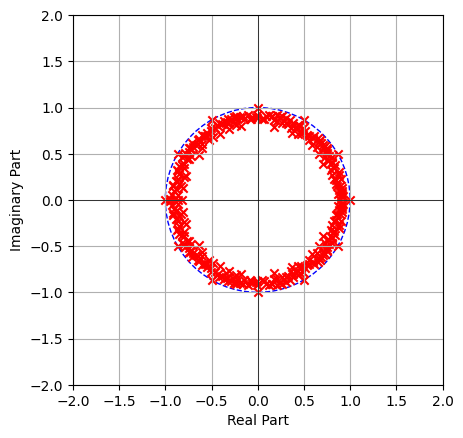

In [ ]:
# Assuming koop_eigenvals is already defined
koop_eigenvals = np.diag(dmd_model.lamda)

filtered_eigenvals = koop_eigenvals[np.abs(koop_eigenvals) > 0.8]

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the unit circle
unit_circle = plt.Circle((0, 0), 1, color="b", fill=False, linestyle="--")
ax.add_artist(unit_circle)

# Plot the eigenvalues
ax.scatter(
    filtered_eigenvals.real, filtered_eigenvals.imag, color="r", marker="x"
)

# Set the axis limits
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])

# Add grid, legend, and labels
ax.grid(True)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")

# Show the plot
plt.show()

In [ ]:
def predict_plot(states, sample, plot=True, plot_num_states=64):
    x0_td = states[
        :NUM_STATES,
        sample * NUM_ITERATIONS : (sample * NUM_ITERATIONS) + NUM_DELAYS + 1,
    ].T.numpy()

    plot_num_states = min(plot_num_states, NUM_STATES)

    Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_ITERATIONS - 1 - NUM_DELAYS)
    Xkoop = np.vstack([x0_td, Xkoop])

    if plot:
        fig, axs = plt.subplots(
            plot_num_states, 1, sharex=True, tight_layout=True, figsize=(12, 12)
        )
        for state_idx in range(0, plot_num_states):
            axs[state_idx].plot(
                t,
                states[
                    state_idx,
                    sample * NUM_ITERATIONS : sample * NUM_ITERATIONS + NUM_ITERATIONS,
                ],
                "-",
                color="b",
                label="True States",
            )
            axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
            axs[state_idx].set(ylabel=f"state {state_idx}")

        for i in range(0, plot_num_states):
            axs[i].axvline(x=t[NUM_DELAYS])

    return Xkoop


def test_error(true_states, pred_states, num_states=None):
    if num_states:
        loss = F.l1_loss(
            true_states[:num_states, -1], torch.nn.functional.relu(torch.Tensor(pred_states)).T[:num_states, -1], reduction="sum"
        )
    else:
        loss = F.l1_loss(
            true_states[:, -1], torch.nn.functional.relu(torch.Tensor(pred_states)).T[:, -1], reduction="sum"
        )
    return loss

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


102
Error: 8865.716796875


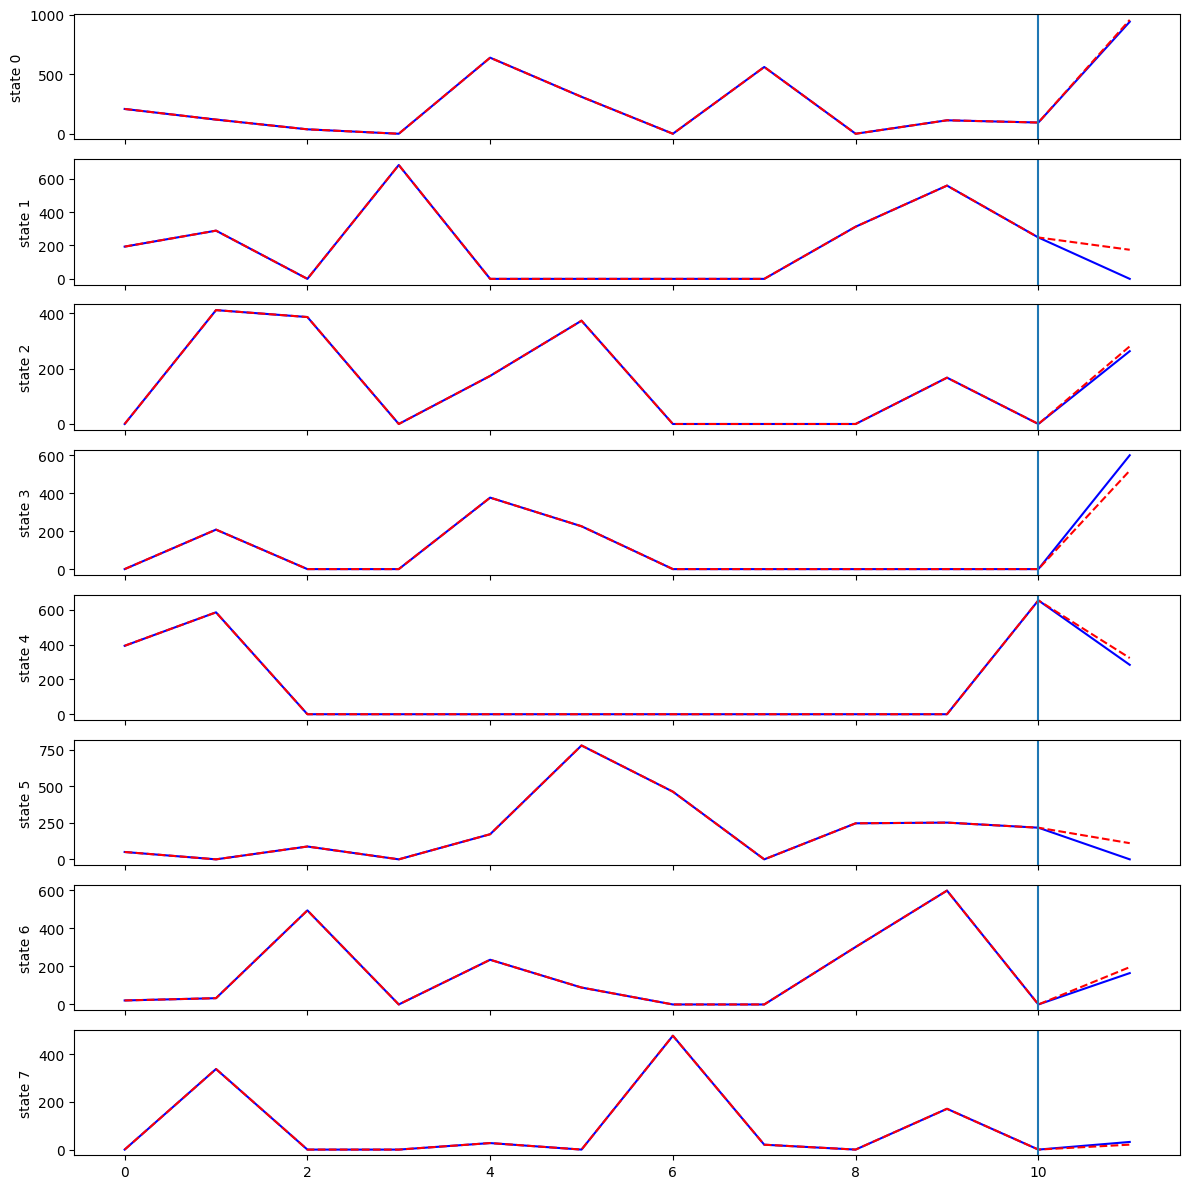

In [ ]:
SAMPLE = np.random.choice(NUM_TRAJECTORIES)
Xkoop = predict_plot(train_states, sample=0, plot_num_states=NUM_STATES_OF_INTEREST//8)
error = test_error(
    true_states=train_states[
        :, SAMPLE * NUM_ITERATIONS : SAMPLE * NUM_ITERATIONS + NUM_ITERATIONS
    ],
    pred_states=Xkoop,
    num_states=NUM_STATES_OF_INTEREST,
)

print(SAMPLE)
print(f"Error: {error.item()}")

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


435
Error: 1685.373291015625


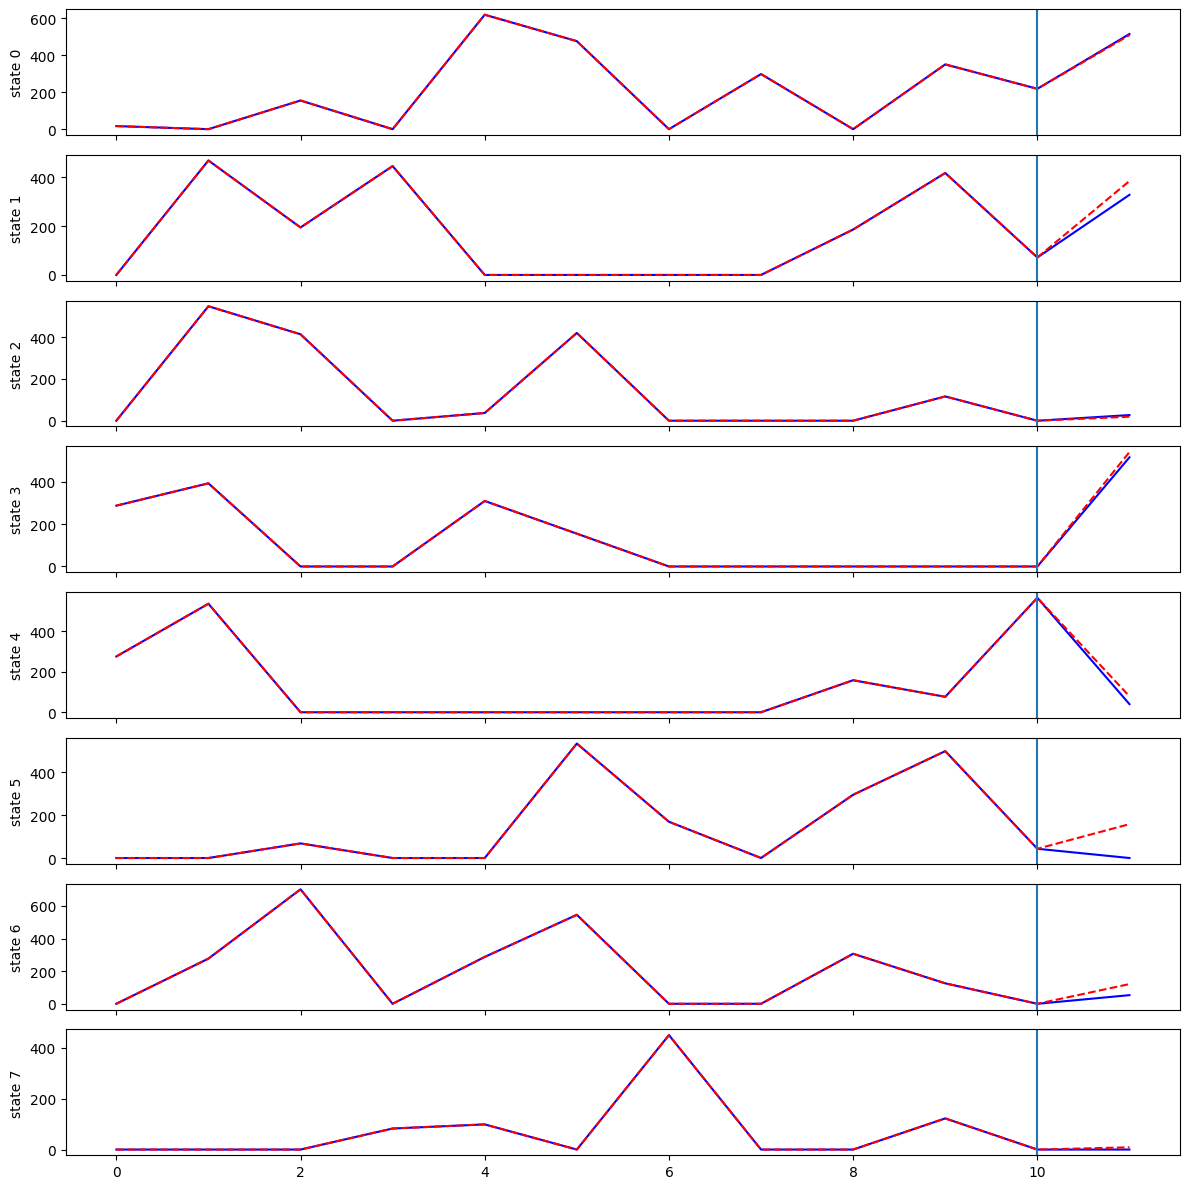

In [ ]:
SAMPLE = np.random.choice(1000)
Xkoop = predict_plot(test_states, sample=SAMPLE, plot_num_states=NUM_STATES_OF_INTEREST//8)
error = test_error(
    true_states=test_states[
        :, SAMPLE * NUM_ITERATIONS : SAMPLE * NUM_ITERATIONS + NUM_ITERATIONS
    ],
    pred_states=Xkoop,
    num_states=NUM_STATES_OF_INTEREST,
)

print(SAMPLE)
print(f"Error: {error.item()}")

In [ ]:
# Load model
file_path = f"../saved_weights/mnist_start{LAYER_START}_scaled_model.safetensors"
metadata = safetensors_metadata_parser(file_path=file_path)
scaled_model = MLP(
    config=literal_eval(metadata["config"]),
    nonlinearity=metadata["nonlinearity"],
    in_features=784,
    out_features=10,
)
_ = load_model(scaled_model, file_path, device="cuda:0")

In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),  # first, convert image to PyTorch tensor
        transforms.Normalize((0.1307,), (0.3081,)),  # normalize inputs
    ]
)
train_set = datasets.MNIST(
    root="/mnt/datasets/", train=True, download=True, transform=transform
)
test_set = datasets.MNIST(
    root="/mnt/datasets/", train=False, download=True, transform=transform
)

In [ ]:
_, accuracy = inference_with_koopman(
    nn_model=scaled_model,
    dmd_model=dmd_model,
    test_set=test_set,
    layer_start=literal_eval(metadata["layer_start"]),
    num_iterations=NUM_ITERATIONS,
    num_delays=NUM_DELAYS,
    num_usable_states=NUM_STATES_OF_INTEREST,
    test_size=100_0,
)
print(accuracy)

tensor(0.9520)
